Correlação:
                   mes  faturamento
mes          1.000000     0.935045
faturamento  0.935045     1.000000
m: 17.5385
b: 6.0
Previsão para mês 10: 181.38
R²: 0.8743
RMSE: 22.9556


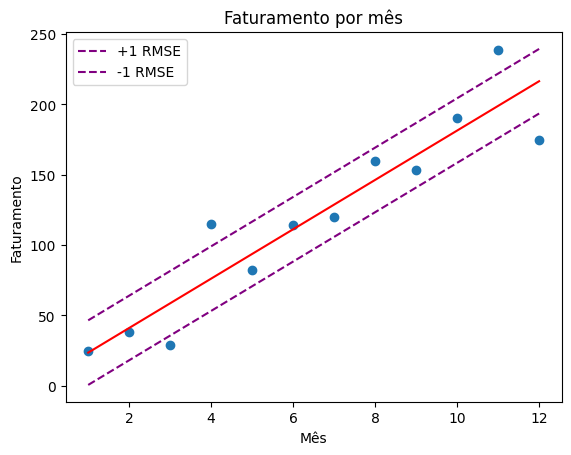


Resumo Statsmodels:
                            OLS Regression Results                            
Dep. Variable:            faturamento   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     69.56
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           8.16e-06
Time:                        05:34:19   Log-Likelihood:                -54.630
No. Observations:                  12   AIC:                             113.3
Df Residuals:                      10   BIC:                             114.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.0000     15.47

In [ ]:
# ==============================
#  1. IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ==============================
# 2. CRIAÇÃO DO DATAFRAME
# ==============================
faturamento = [25,38,29,115,82,114,120,160,153,190,239,175]
mes = list(range(1,13))

data = pd.DataFrame({
    'mes': mes,
    'faturamento': faturamento
})

# ==============================
# 3. VISUALIZAÇÃO INICIAL
# ==============================

plt.figure(figsize=(8,5))
           
x = data['mes']
y = data['faturamento']

plt.scatter(x, y, color='blue', label='Dados reais')
plt.title("Faturamento por mês")
plt.xlabel("Mês")
plt.ylabel("Faturamento")


# Correlação
print("Correlação:\n", data.corr())

# ==============================
#  4. REGRESSÃO LINEAR MANUAL
# ==============================

# Cálculo do coeficiente angular (m)
m = (len(x)*(x*y).sum() - x.sum()*y.sum()) / (len(x)*(x**2).sum() - (x.sum())**2)

# Cálculo do intercepto (b)
b = (y.sum() - m*x.sum()) / len(x)

print("m:", round(m,4))
print("b:", round(b,4))

# ==============================
#  5. PREDIÇÕES
# ==============================

# Predição para todos os meses
data['predicao'] = m * x + b

# Exemplo de previsão futura
x_pred = 10
y_pred = m * x_pred + b
print(f"Previsão para mês {x_pred}: {y_pred:.2f}")

# ==============================
#  6. GRÁFICO COM REGRESSÃO
# ==============================

plt.plot(x, data['predicao'], color='red', label='Regressão Linear')

# ==============================
# 7. MÉTRICAS (R² E RMSE)
# ==============================

# Resíduos
data['residuos'] = y - data['predicao']

# Soma quadrática dos resíduos
SQres = (data['residuos']**2).sum()

# Soma total
media = y.mean()
SQtot = ((y - media)**2).sum()

# R²
r2 = 1 - (SQres / SQtot)

# RMSE
rmse = np.sqrt(SQres / len(data))

print("R²:", round(r2,4))
print("RMSE:", round(rmse,4))

# ==============================
# 8. INTERVALOS (DESVIO)
# ==============================

plt.plot(x, data['predicao'] + rmse, '--', color='purple', label='Intervalo de erro (+1 RMSE)')
plt.plot(x, data['predicao'] - rmse, '--', color='purple', label='Intervalo de erro (-1 RMSE)')

plt.legend()
plt.show()

# ==============================
# 9. REGRESSÃO - STATSMODELS
# ==============================

X_sm = sm.add_constant(x.values)
modelo_sm = sm.OLS(y, X_sm).fit()

sm_pred = modelo_sm.predict()

print("\nResumo Statsmodels:")
print(modelo_sm.summary())

# RMSE
from statsmodels.tools.eval_measures import rmse
print("RMSE (Statsmodels):", rmse(y, sm_pred))

# ==============================
# 10. REGRESSÃO - SKLEARN
# ==============================

X_sk = np.array(x).reshape(-1,1)

modelo_sk = LinearRegression()
modelo_sk.fit(X_sk, y)

sk_pred = modelo_sk.predict(X_sk)

# Métricas
r2_sk = modelo_sk.score(X_sk, y)
rmse_sk = np.sqrt(mean_squared_error(y, sk_pred))

print("\nSklearn:")
print("m:", modelo_sk.coef_[0])
print("b:", modelo_sk.intercept_)
print("R²:", r2_sk)
print("RMSE:", rmse_sk)

# ==============================
# 11. COMPARAÇÃO FINAL
# ==============================

print("\nComparação das predições:\n")
print("Manual:", data['predicao'].values)
print("Statsmodels:", sm_pred)
print("Sklearn:", sk_pred)




Visualização inicial (head):
   Mes     Manual  Statsmodels    Sklearn
0    1  23.538462    23.538462  23.538462
1    2  41.076923    41.076923  41.076923
2    3  58.615385    58.615385  58.615385
3    4  76.153846    76.153846  76.153846
4    5  93.692308    93.692308  93.692308


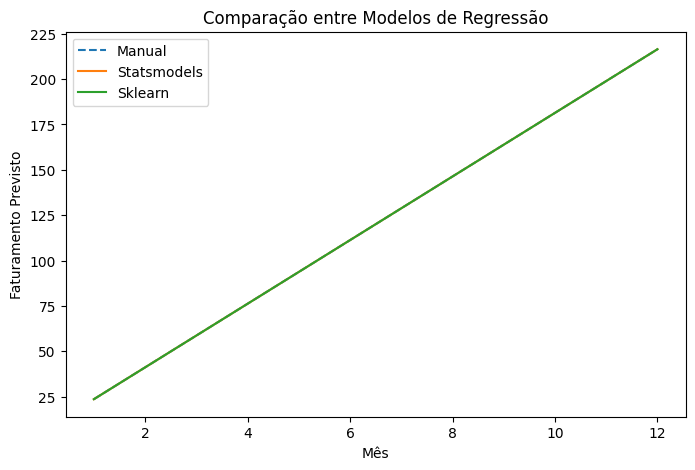

In [ ]:
# ==============================
# 12. VISUALIZAÇÃO
# ==============================

# Criando DataFrame de comparação
comparacao = pd.DataFrame({
    'Mes': x,
    'Manual': data['predicao'],
    'Statsmodels': sm_pred,
    'Sklearn': sk_pred
})

# Visualizar apenas primeiros dados
print("\nVisualização inicial (head):")
print(comparacao.head())

# ==============================
# 13. GRÁFICO COMPARATIVO
# ==============================

plt.figure(figsize=(8,5))

plt.plot(comparacao['Mes'], comparacao['Manual'], label='Manual', linestyle='--')
plt.plot(comparacao['Mes'], comparacao['Statsmodels'], label='Statsmodels')
plt.plot(comparacao['Mes'], comparacao['Sklearn'], label='Sklearn')

plt.title("Comparação entre Modelos de Regressão")
plt.xlabel("Mês")
plt.ylabel("Faturamento Previsto")
plt.legend()


plt.grid(alpha=0.3)
plt.show()